CSV DATASET
   CustomerID  Age  Gender   Income  Purchases Churn
0        1001   25    Male  35000.0          5    No
1        1002   34  Female  55000.0          8    No
2        1003   45    Male  72000.0         12    No
3        1004   29  Female  40000.0          3   Yes
4        1005   52    Male  85000.0         15    No
JSON DATASET
   CustomerID  Age  Gender  Income  Purchases Churn
0        2001   28    Male   42000          5    No
1        2002   31  Female   48000          7    No
2        2003   24    Male   35000          2   Yes
3        2004   45  Female   76000         12    No
4        2005   39    Male   61000          9    No
SQL DATASET
   CustomerID  Age  Gender  Income  Purchases Churn
0        2001   28    Male   42000          5    No
1        2002   31  Female   48000          7    No
2        2003   24    Male   35000          2   Yes
3        2004   45  Female   76000         12    No
4        2005   39    Male   61000          9    No
API DATASET
   id    

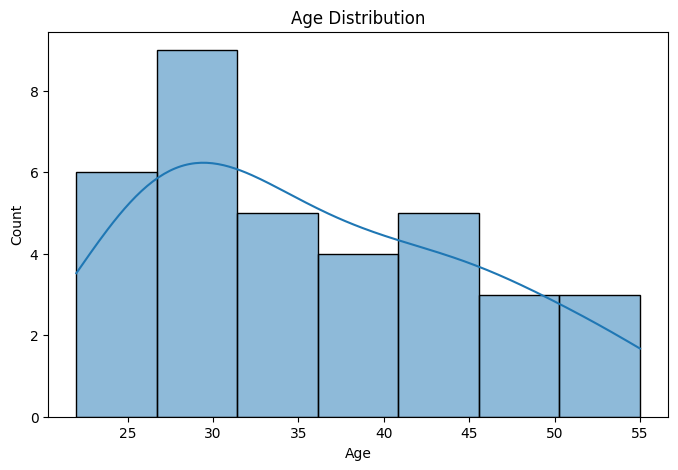

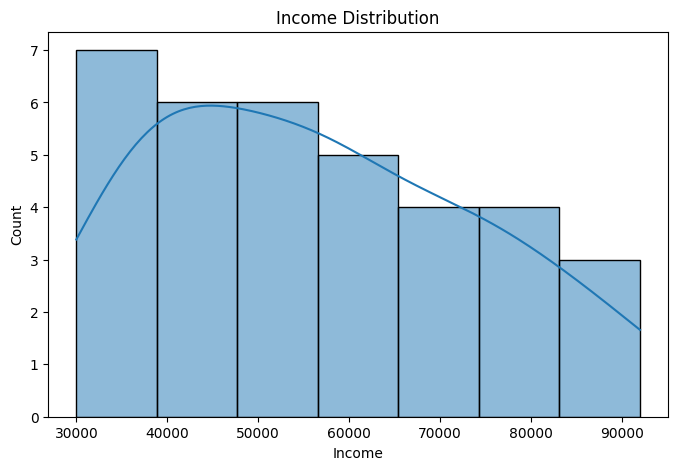

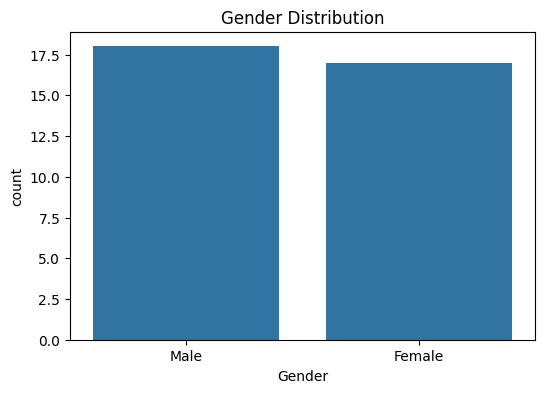

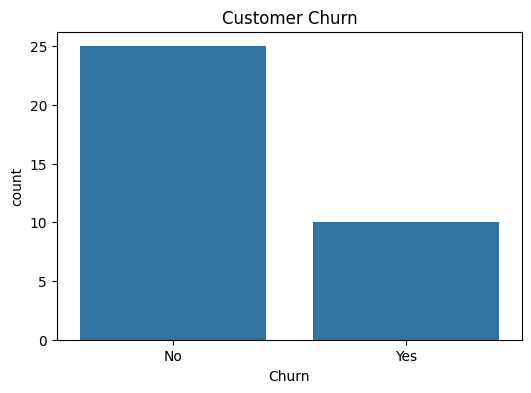

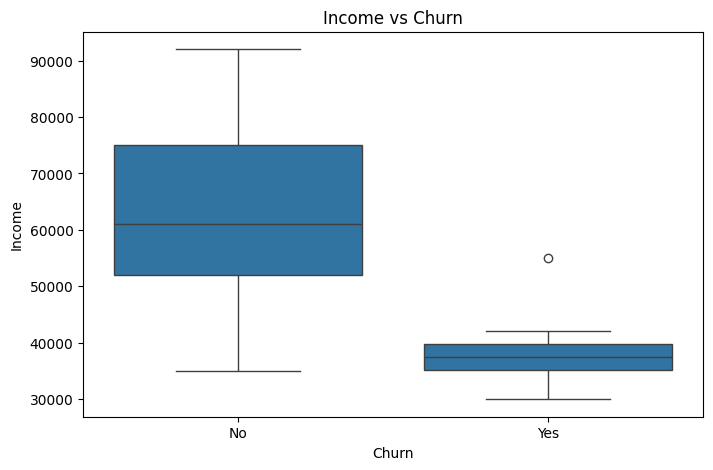

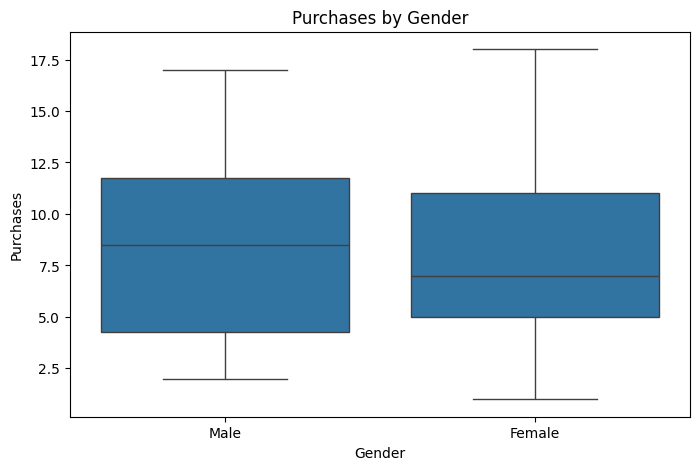

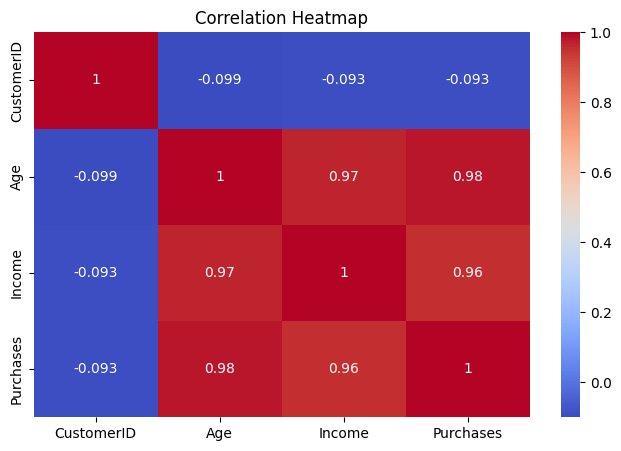

Cleaned Dataset Saved Successfully
PROJECT COMPLETED SUCCESSFULLY
Data collected from CSV, JSON, SQL and API
Data cleaning completed
Missing values handled
Duplicate values removed
Data profiling completed
EDA completed successfully
Correlation analysis completed
Cleaned dataset saved


In [1]:
# ==========================================
# CUSTOMER CHURN ANALYSIS PROJECT
# ==========================================

# Import Libraries

import pandas as pd
import numpy as np
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD CSV DATA
# ==========================================

df_csv = pd.read_csv("customer.csv")

print("CSV DATASET")
print(df_csv.head())

# ==========================================
# LOAD JSON DATA
# ==========================================

df_json = pd.read_json("customer.json")

print("JSON DATASET")
print(df_json.head())

# ==========================================
# CREATE SQL DATABASE
# ==========================================

conn = sqlite3.connect("customer.db")

df_json.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

df_sql = pd.read_sql(
    "SELECT * FROM customers",
    conn
)

print("SQL DATASET")
print(df_sql.head())

# ==========================================
# FETCH API DATA
# ==========================================

url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(url)

api_data = response.json()

df_api = pd.DataFrame(api_data)

print("API DATASET")
print(df_api.head())

# ==========================================
# MERGE DATASETS
# ==========================================

df = pd.concat(
    [df_csv, df_json],
    ignore_index=True
)

print("COMBINED DATASET SHAPE")
print(df.shape)

# ==========================================
# DATASET INFO
# ==========================================

print("DATASET INFO")
print(df.info())

print("STATISTICAL SUMMARY")
print(df.describe())

print("FIRST 5 ROWS")
print(df.head())

# ==========================================
# DATA PROFILING
# ==========================================

print("DATASET SHAPE")
print(df.shape)

print("COLUMN NAMES")
print(df.columns)

print("MISSING VALUES")
print(df.isnull().sum())

print("DUPLICATE VALUES")
print(df.duplicated().sum())

# ==========================================
# REMOVE DUPLICATES
# ==========================================

df.drop_duplicates(inplace=True)

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("MISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# ==========================================
# AGE DISTRIBUTION
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

# ==========================================
# INCOME DISTRIBUTION
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(df["Income"], kde=True)
plt.title("Income Distribution")
plt.show()

# ==========================================
# GENDER DISTRIBUTION
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

# ==========================================
# CHURN DISTRIBUTION
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn")
plt.show()

# ==========================================
# INCOME VS CHURN
# ==========================================

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Churn",
    y="Income",
    data=df
)

plt.title("Income vs Churn")
plt.show()

# ==========================================
# PURCHASES VS GENDER
# ==========================================

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Gender",
    y="Purchases",
    data=df
)

plt.title("Purchases by Gender")
plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# SAVE CLEANED DATASET
# ==========================================

df.to_csv(
    "Cleaned_Customer_Data.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully")

# ==========================================
# PROJECT CONCLUSION
# ==========================================

print("PROJECT COMPLETED SUCCESSFULLY")
print("Data collected from CSV, JSON, SQL and API")
print("Data cleaning completed")
print("Missing values handled")
print("Duplicate values removed")
print("Data profiling completed")
print("EDA completed successfully")
print("Correlation analysis completed")
print("Cleaned dataset saved")